In [3]:
import pandas as pd

df = pd.read_csv("data/reddit_data.csv", low_memory=False)
df.head()

,title,score,id,url,comms_num,created,body,timestamp
0,A Right Wing Group in Texas Is Making up Fake ...,166,ov1ll3,https://www.vice.com/en/article/wx5bg5/blm-whi...,34,1.627710e+09,NaN,2021-07-31 08:35:47
1,DOJ sues Texas over Gov. Abbott’s order for la...,85,ouwc9i,https://www.kxan.com/news/texas-politics/doj-s...,17,1.627688e+09,NaN,2021-07-31 02:26:12
2,"From white evangelicals to QAnon believers, wh...",57,ouqkxi,https://www.modbee.com/news/coronavirus/articl...,27,1.627671e+09,NaN,2021-07-30 21:45:09
3,DeSantis says he’ll sign order allowing parent...,269,oun2lc,https://www.orlandosentinel.com/politics/os-ne...,138,1.627660e+09,NaN,2021-07-30 18:43:05
4,"Show on the road: In Utah, Florida Gov. Ron De...",31,ouipnz,https://www.tallahassee.com/story/news/politic...,28,1.627644e+09,NaN,2021-07-30 14:21:54


In [4]:
#Dropping the 'body' column
df = df.drop(columns=["body"], errors="ignore")

#Removing rows with missing titles
df = df.dropna(subset=["title"])

#Remove noise by removing very short OR bad titles
df = df[df["title"].str.len() > 15]

#Converting the timestamp from text to date
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["timestamp"] = df["timestamp"].dt.date

#Removing duplicates
df = df.drop_duplicates(subset="id")

df.shape
df.head()

,title,score,id,url,comms_num,created,timestamp
0,A Right Wing Group in Texas Is Making up Fake ...,166,ov1ll3,https://www.vice.com/en/article/wx5bg5/blm-whi...,34,1.627710e+09,2021-07-31
1,DOJ sues Texas over Gov. Abbott’s order for la...,85,ouwc9i,https://www.kxan.com/news/texas-politics/doj-s...,17,1.627688e+09,2021-07-31
2,"From white evangelicals to QAnon believers, wh...",57,ouqkxi,https://www.modbee.com/news/coronavirus/articl...,27,1.627671e+09,2021-07-30
3,DeSantis says he’ll sign order allowing parent...,269,oun2lc,https://www.orlandosentinel.com/politics/os-ne...,138,1.627660e+09,2021-07-30
4,"Show on the road: In Utah, Florida Gov. Ron De...",31,ouipnz,https://www.tallahassee.com/story/news/politic...,28,1.627644e+09,2021-07-30


In [ ]:
RQ1: Sentiment analysis

In [18]:
!pip install textblob

In [5]:
from textblob import TextBlob

df["sentiment"] = df["title"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

df["sentiment_label"] = df["sentiment"].apply(
    lambda x: "positive" if x > 0 else "negative" if x < 0 else "neutral"
)

df[["title", "sentiment", "sentiment_label"]].head()

df["sentiment_label"].value_counts()

sentiment_label
neutral     5709
positive    2606
negative    1715
Name: count, dtype: int64

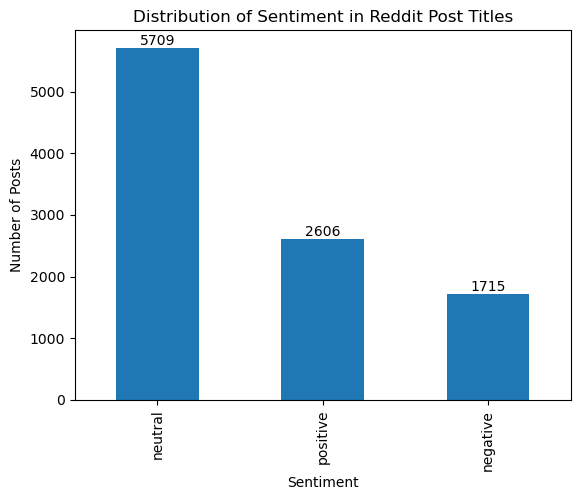

In [12]:
import matplotlib.pyplot as plt

ax = df["sentiment_label"].value_counts().plot(kind="bar")

plt.title("Distribution of Sentiment in Reddit Post Titles")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
The bar chart shows the distribution of sentiment across Reddit post titles.
It can be observed that neutral sentiment dominates, indicating that political discussions tend to be more critical or controversial in nature.

In [ ]:
RQ2: What are the most common themes in political discussions?

In [15]:
from sklearn.feature_extraction.text import CountVectorizer\

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=15
)

X = vectorizer.fit_transform(df["title"])

word_counts = X.toarray().sum(axis=0)

words_df = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": word_counts
})

words_df = words_df.sort_values(by="count", ascending=False)

words_df

,word,count
1,biden,1811
14,trump,1327
13,texas,772
6,gop,732
10,says,671
4,democrats,651
7,house,609
3,covid,580
8,new,553
0,abortion,520


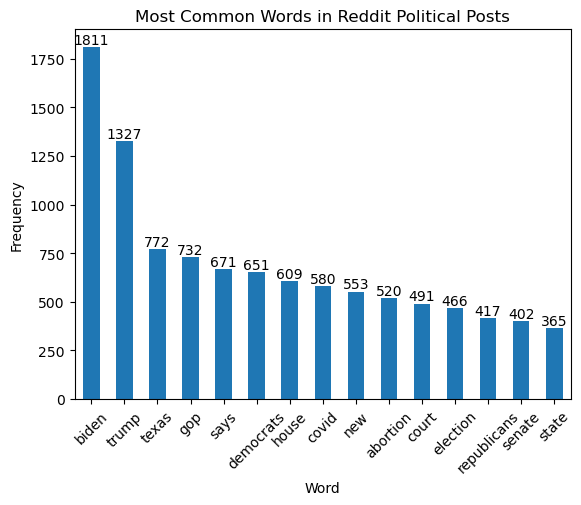

In [16]:
import matplotlib.pyplot as plt

ax = words_df.plot(
    kind="bar",
    x="word",
    y="count",
    legend=False
)

plt.title("Most Common Words in Reddit Political Posts")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
RQ3: Engagement Analysis

In [ ]:
Average score by sentiment

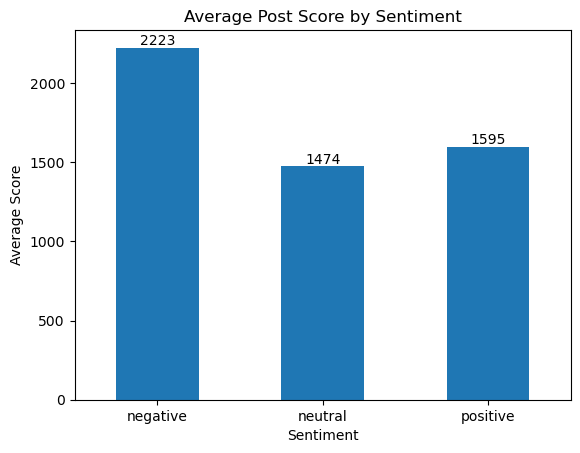

In [13]:
ax = df.groupby("sentiment_label")["score"].mean().plot(kind="bar")

plt.title("Average Post Score by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Score")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.show()

In [ ]:
Average comments by sentiment

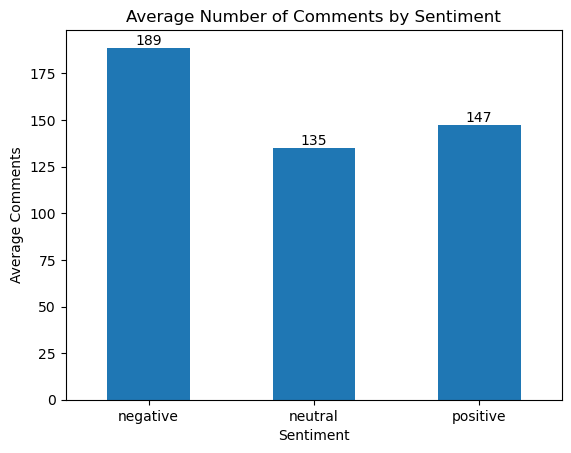

In [14]:
ax = df.groupby("sentiment_label")["comms_num"].mean().plot(kind="bar")

plt.title("Average Number of Comments by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Comments")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.show()

In [ ]:
Scatter plot

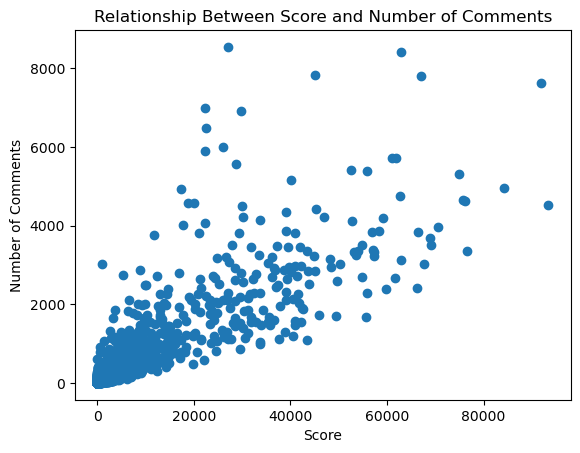

In [10]:
plt.scatter(df["score"], df["comms_num"])

plt.title("Relationship Between Score and Number of Comments")
plt.xlabel("Score")
plt.ylabel("Number of Comments")

plt.show()